In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(r"D:\AAA_nus\Sem2\IT5006\project")
os.chdir(PROJECT_ROOT)
print("Now CWD =", Path.cwd())

FIG_DIR = PROJECT_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("FIG_DIR =", FIG_DIR.resolve())


Now CWD = D:\AAA_nus\Sem2\IT5006\project
FIG_DIR = D:\AAA_nus\Sem2\IT5006\project\docs\figures


In [2]:
# =========================================
# IT5006 Project (AY25/26 S2) - EDA Temporal Pattern Analysis
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 120

In [3]:
# DATA_PATH = "Crimes_-_2001_to_Present_20260213.csv"

# df = pd.read_csv(DATA_PATH)

# print("Raw shape:", df.shape)
# display(df.head())
# display(df.dtypes)

import pandas as pd
import requests
from io import StringIO
from pathlib import Path

# 1) 与 Spatial 对齐的时间范围
START_DATE = "2015-01-01T00:00:00.000"
END_DATE   = "2025-01-01T00:00:00.000"  # exclusive

# 2) 缓存到你本地项目目录（只下载一次）
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "chicago_2015_2024_temporal.csv"

# 3) Socrata CSV endpoint（和 Spatial 一样的数据源）
BASE = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"

# 4) 只下载 Temporal 真正需要的最小列（尽量少改后续代码）
SELECT = "date,primary_type"

WHERE = f"date >= '{START_DATE}' AND date < '{END_DATE}'"

def download_temporal_csv(out_path: Path, limit=50000):
    session = requests.Session()
    offset = 0
    first = True

    while True:
        params = {
            "$select": SELECT,
            "$where": WHERE,
            "$order": "date ASC",
            "$limit": limit,
            "$offset": offset,
        }
        r = session.get(BASE, params=params, timeout=60)
        r.raise_for_status()

        chunk = pd.read_csv(StringIO(r.text))
        if chunk.empty:
            break

        chunk.to_csv(out_path, mode="w" if first else "a", index=False, header=first)
        first = False

        offset += limit
        print("downloaded rows:", offset)

    print("Saved CSV to:", out_path.resolve())

# 5) 如果本地没有缓存就下载一次；有就直接读
if not DATA_PATH.exists():
    print("Local CSV not found. Downloading once via API...")
    download_temporal_csv(DATA_PATH)
else:
    print("Using cached CSV:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH)

# 6) 把 API 的列名改成你后续 cell 需要的列名（关键：这样后面基本不用改）
df = df.rename(columns={
    "date": "Date",
    "primary_type": "Primary Type"
})

print("Raw shape:", df.shape)
display(df.head())
display(df.dtypes)


Local CSV not found. Downloading once via API...
downloaded rows: 50000
downloaded rows: 100000
downloaded rows: 150000
downloaded rows: 200000
downloaded rows: 250000
downloaded rows: 300000
downloaded rows: 350000
downloaded rows: 400000
downloaded rows: 450000
downloaded rows: 500000
downloaded rows: 550000
downloaded rows: 600000
downloaded rows: 650000
downloaded rows: 700000
downloaded rows: 750000
downloaded rows: 800000
downloaded rows: 850000
downloaded rows: 900000
downloaded rows: 950000
downloaded rows: 1000000
downloaded rows: 1050000
downloaded rows: 1100000
downloaded rows: 1150000
downloaded rows: 1200000
downloaded rows: 1250000
downloaded rows: 1300000
downloaded rows: 1350000
downloaded rows: 1400000
downloaded rows: 1450000
downloaded rows: 1500000
downloaded rows: 1550000
downloaded rows: 1600000
downloaded rows: 1650000
downloaded rows: 1700000
downloaded rows: 1750000
downloaded rows: 1800000
downloaded rows: 1850000
downloaded rows: 1900000
downloaded rows: 1950

,Date,Primary Type
0,2015-01-01T00:00:00.000,DECEPTIVE PRACTICE
1,2015-01-01T00:00:00.000,DECEPTIVE PRACTICE
2,2015-01-01T00:00:00.000,OFFENSE INVOLVING CHILDREN
3,2015-01-01T00:00:00.000,DECEPTIVE PRACTICE
4,2015-01-01T00:00:00.000,DECEPTIVE PRACTICE


Date            object
Primary Type    object
dtype: object

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df[(df["Date"].dt.year >= 2015) & (df["Date"].dt.year <= 2024)].copy()

print("After filter shape:", df.shape)

After filter shape: (2519528, 2)


In [5]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["weekday"] = df["Date"].dt.day_name()
df["hour"] = df["Date"].dt.hour

Saved: D:\AAA_nus\Sem2\IT5006\project\docs\figures\temporal_yearly.png


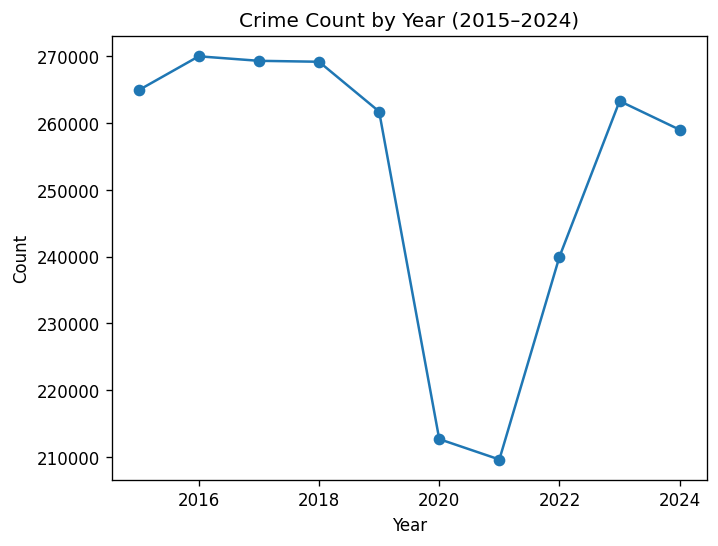

In [7]:
year_counts = df.groupby("year").size()

year_counts.plot(marker="o")
plt.title("Crime Count by Year (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Count")

###Wenn added###
out = FIG_DIR / "temporal_yearly.png"
plt.gcf().savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out.resolve())


plt.show()

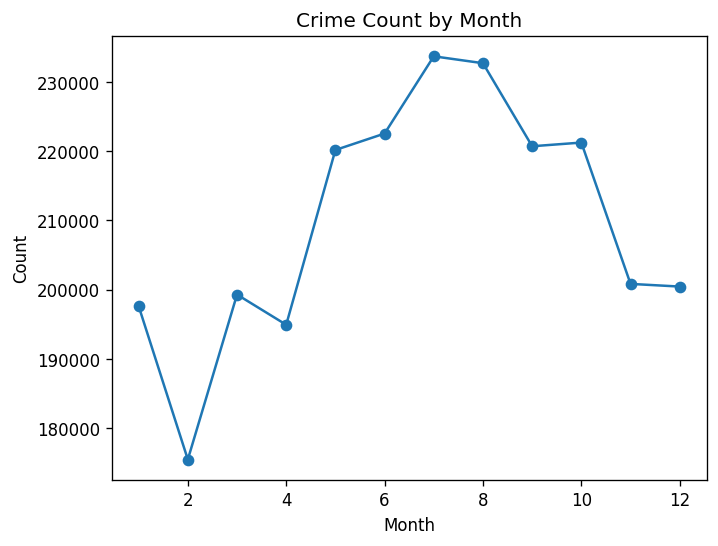

In [9]:
month_counts = df.groupby("month").size()

month_counts.plot(marker="o")
plt.title("Crime Count by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

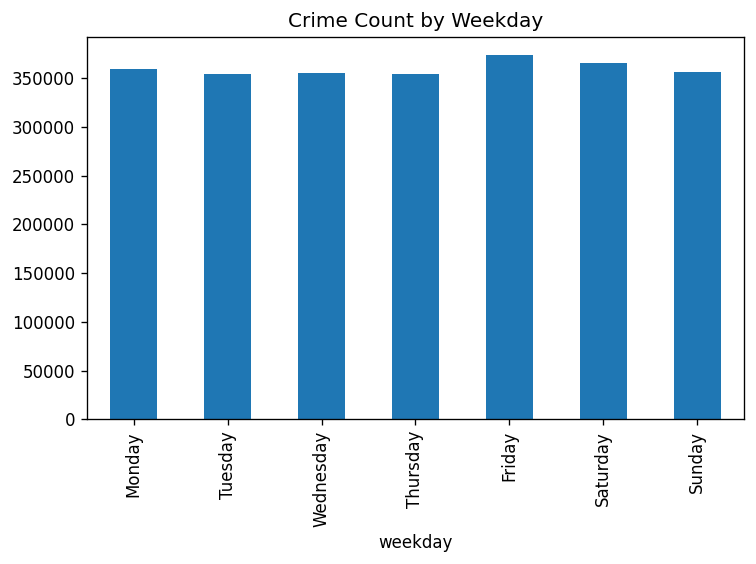

In [10]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_counts = df["weekday"].value_counts().reindex(weekday_order)
weekday_counts.plot(kind="bar")
plt.title("Crime Count by Weekday")
plt.tight_layout()
plt.show()

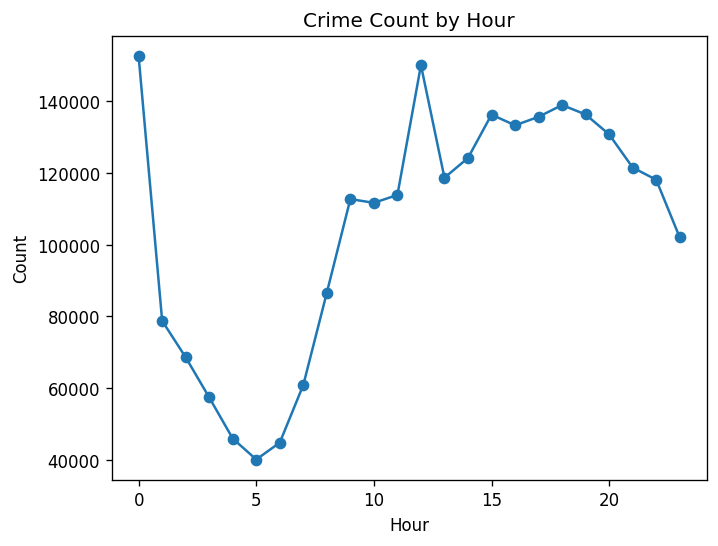

In [11]:
hour_counts = df.groupby("hour").size()

hour_counts.plot(marker="o")
plt.title("Crime Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

Saved: D:\AAA_nus\Sem2\IT5006\project\docs\figures\weekday_hour_heatmap.png


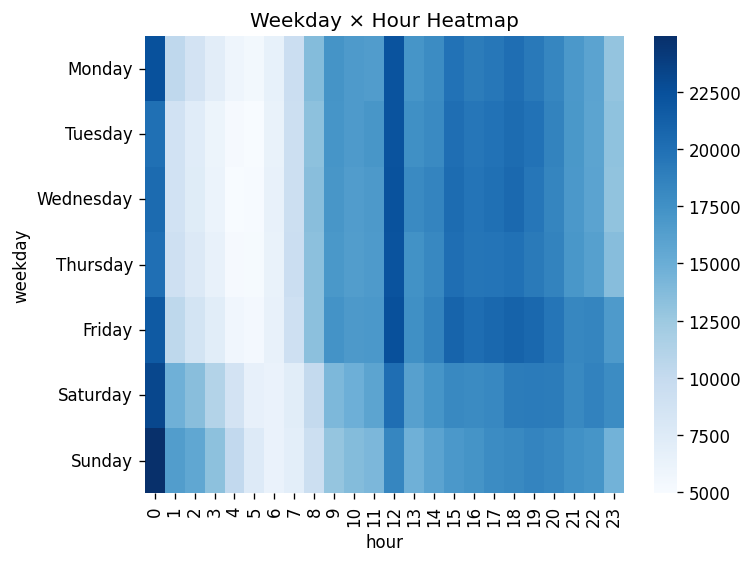

In [12]:
pivot = pd.pivot_table(df, index="weekday", columns="hour", aggfunc="size").reindex(weekday_order)

sns.heatmap(pivot, cmap="Blues")
plt.title("Weekday × Hour Heatmap")
plt.tight_layout()

###Wenn added###
out = FIG_DIR / "weekday_hour_heatmap.png"
plt.gcf().savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out.resolve())

plt.show()

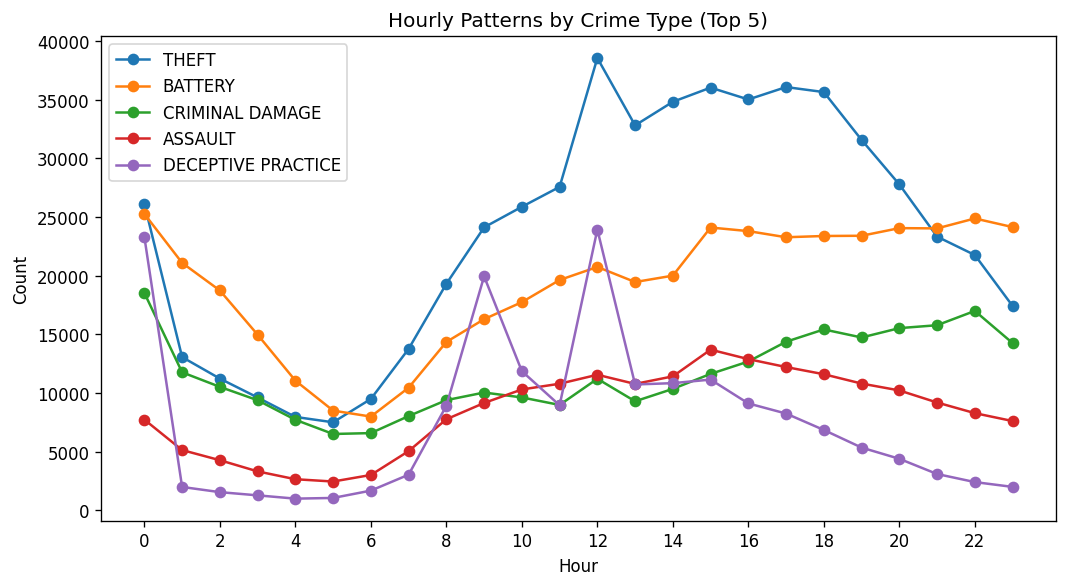

In [ ]:
top5 = df["Primary Type"].value_counts().head(5).index.tolist()

tmp = (
    df[df["Primary Type"].isin(top5)]
    .groupby(["Primary Type", "hour"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(9, 5))
for t in top5:
    sub = tmp[tmp["Primary Type"] == t].sort_values("hour")
    plt.plot(sub["hour"], sub["count"], marker="o", label=t)

plt.title("Hourly Patterns by Crime Type (Top 5)")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()



plt.show()

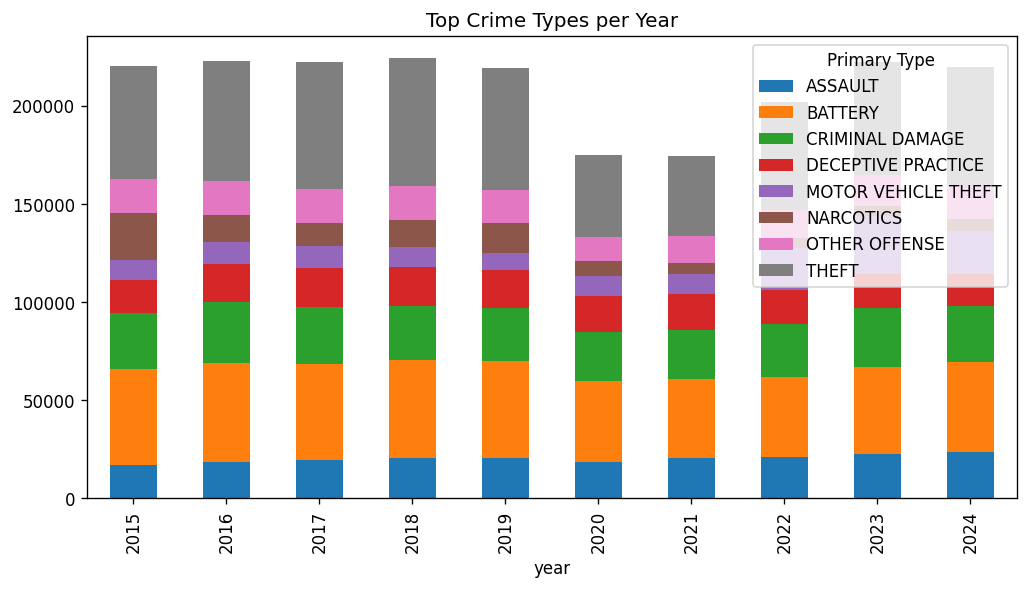

In [ ]:
top_types = df["Primary Type"].value_counts().head(8).index

tmp = df[df["Primary Type"].isin(top_types)]

pivot = tmp.groupby(["year", "Primary Type"]).size().unstack(fill_value=0)

pivot.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Top Crime Types per Year")
plt.show()

# EDA — Temporal Pattern Analysis (Report Version)
## Exploratory Data Analysis – Temporal Patterns of Chicago Crimes (2015–2024)

To better understand when crimes are most likely to occur, we conducted a temporal analysis of Chicago crime records from 2015 to 2024 across multiple time scales, including yearly, monthly, weekly, and hourly patterns. The goal is to identify recurring trends and peak periods that may provide insights into crime dynamics.

### Yearly Trend

The annual crime counts remain relatively stable between 2015 and 2019, fluctuating around 265k–270k incidents per year. A significant decline is observed in 2020–2021, where total crimes drop sharply to approximately 210k. This sudden decrease likely corresponds to reduced mobility and social activities during the COVID-19 pandemic. From 2022 onwards, crime levels gradually rebound, approaching pre-pandemic levels by 2023–2024. Overall, the long-term trend suggests that crime volumes are generally stable but sensitive to major societal disruptions.

### Monthly / Seasonal Patterns

Monthly analysis reveals clear seasonality. Crime counts increase steadily from spring and peak during the summer months, especially July and August, before declining again in winter. February consistently records the lowest crime counts. This seasonal behavior may be associated with warmer weather, increased outdoor activities, and higher population interactions during summer, which create more opportunities for crimes to occur.

### Weekly Distribution

Crimes are relatively evenly distributed across weekdays, with only minor differences. Slightly higher counts are observed on Fridays and Saturdays, indicating a modest weekend effect. However, the variation between days is small compared to seasonal or hourly changes, suggesting that crime occurrence is not strongly dependent on the day of the week.

### Hourly Patterns

Hourly analysis shows a strong daily cycle. Crime levels are lowest during early morning hours (approximately 3–6 AM). After 8 AM, incidents increase rapidly and remain elevated throughout the afternoon and evening. A notable peak appears around noon and continues until late evening (approximately 6–9 PM). This pattern aligns with typical human activity schedules, where higher movement and interactions during daytime and evening lead to more reported incidents.

### Weekday × Hour Heatmap

The heatmap further confirms that time-of-day effects dominate over weekday effects. High crime intensities are consistently observed during afternoon and evening hours across all days, while early mornings remain low. The similarity of patterns across weekdays suggests that daily routines influence crime timing more strongly than weekly cycles.

### Crime Type Differences

Analysis of the top crime types shows that theft-related offenses (e.g., THEFT, BATTERY, CRIMINAL DAMAGE) consistently contribute the largest share of incidents each year. Although total counts decrease during the pandemic period, the relative composition of crime types remains stable, indicating persistent underlying crime structures rather than drastic changes in behavior.

Furthermore, hourly patterns differ noticeably across crime categories. When examining the top five crime types, theft-related offenses such as THEFT and BATTERY tend to peak during afternoon and evening hours, while certain offenses show relatively flatter or delayed activity curves. This indicates that different crime types follow distinct temporal behaviors rather than sharing a uniform daily cycle. Such heterogeneity suggests that incorporating crime-type-specific time features may improve future predictive or resource allocation models.

### Key Insights

Overall, temporal patterns demonstrate that:

- Crime levels are stable annually but affected by external events (e.g., pandemic)

- Clear seasonal peaks occur in summer months

- Weak weekday effects

- Strong hourly cycles with afternoon/evening peaks

- Theft-related crimes dominate consistently

These findings suggest that time-based features (year, month, season, hour) are informative variables for future predictive modeling or resource allocation strategies.